In [17]:
# Insérez votre code ici
import pandas as pd
import numpy as np
from sklearn import svm
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import preprocessing

wine = pd.read_csv("./data/wine.csv")
wine

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [18]:
data = wine.drop('Wine',axis = 1)
target = wine['Wine']
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.2)

scaler = preprocessing.StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
#SVM classifier
clf = svm.SVC(gamma=0.01,  kernel='poly')
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)
pd.crosstab(y_test, y_pred, rownames=['Classe réelle'], colnames=['Classe prédite'])
# bad performance, we need to fine tune hyperparameters


Classe prédite,2
Classe réelle,
1,14
2,16
3,6


In [20]:
parametres = {'C':[0.1,1,10], 'kernel':['rbf','linear', 'poly'], 'gamma':[0.001, 0.1, 0.5]}
grid_clf = GridSearchCV(estimator=clf, param_grid=parametres)
grille = grid_clf.fit(X_train_scaled,y_train)
print(pd.DataFrame.from_dict(grille.cv_results_).loc[:,['params', 'mean_test_score']]) 


                                            params  mean_test_score
0      {'C': 0.1, 'gamma': 0.001, 'kernel': 'rbf'}         0.387438
1   {'C': 0.1, 'gamma': 0.001, 'kernel': 'linear'}         0.985714
2     {'C': 0.1, 'gamma': 0.001, 'kernel': 'poly'}         0.387438
3        {'C': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}         0.950739
4     {'C': 0.1, 'gamma': 0.1, 'kernel': 'linear'}         0.985714
5       {'C': 0.1, 'gamma': 0.1, 'kernel': 'poly'}         0.844581
6        {'C': 0.1, 'gamma': 0.5, 'kernel': 'rbf'}         0.387438
7     {'C': 0.1, 'gamma': 0.5, 'kernel': 'linear'}         0.985714
8       {'C': 0.1, 'gamma': 0.5, 'kernel': 'poly'}         0.943596
9        {'C': 1, 'gamma': 0.001, 'kernel': 'rbf'}         0.787931
10    {'C': 1, 'gamma': 0.001, 'kernel': 'linear'}         0.971921
11      {'C': 1, 'gamma': 0.001, 'kernel': 'poly'}         0.387438
12         {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}         0.979064
13      {'C': 1, 'gamma': 0.1, 'kernel': 'linear

In [21]:
print(grid_clf.best_params_)
y_pred = grid_clf.predict(X_test_scaled)
pd.crosstab(y_test, y_pred, rownames=['Classe réelle'], colnames=['Classe prédite'])

{'C': 0.1, 'gamma': 0.001, 'kernel': 'linear'}


Classe prédite,1,2,3
Classe réelle,,,
1,14,0,0
2,1,14,1
3,0,0,6


/Users/tristan/git/liora/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/Users/tristan/git/liora/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/Users/tristan/git/liora/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/Users/tristan/git/liora/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/Users/tristan/git/liora/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 2 me

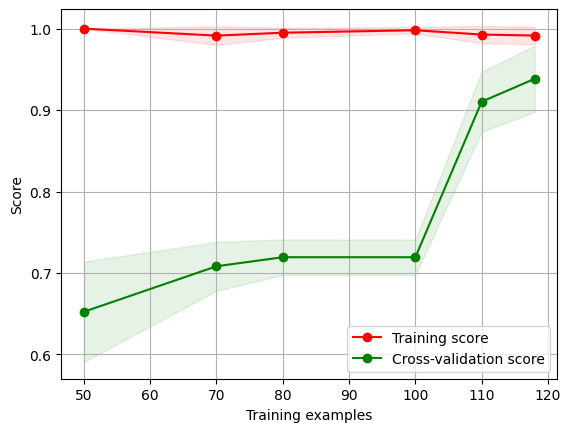

In [22]:
# Learning curve script
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
%matplotlib inline 

train_sizes, train_scores, valid_scores = learning_curve(svm.SVC(kernel='linear', C= 1), data, target, train_sizes=[50, 80, 110, 140], cv=5)

plt.xlabel("Training examples")
plt.ylabel("Score")

train_sizes=[50, 70, 80, 100, 110, 118]

train_sizes, train_scores, test_scores = learning_curve(
    grid_clf, data, target, n_jobs=4, train_sizes=train_sizes)

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)
plt.grid()

plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1,
                 color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="g")
plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
         label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
         label="Cross-validation score")

plt.legend(loc="best")
